In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [2]:
data_train = pd.read_csv("weatherHistory.csv")
data_train.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [3]:
data_train["DOY"] = pd.to_datetime(
    data_train["Formatted Date"].str[:10]
).dt.dayofyear
data_train["Formatted Date"] = pd.to_datetime(
    data_train["Formatted Date"], utc=True
)
data_train["Year"] = data_train["Formatted Date"].dt.year
data_train["DOY"] = data_train["Formatted Date"].dt.dayofyear
data_train_daily = (
    data_train.groupby(["Year", "DOY"])["Temperature (C)"]
    .mean()
    .reset_index()
)
data_train_daily.columns = ["Year", "DOY", "Mean Temperature"]

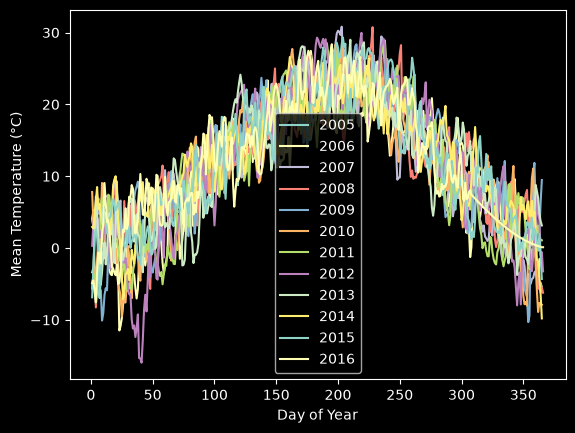

In [4]:
for year, group in data_train_daily.groupby("Year"):
    plt.plot(
        group["DOY"],
        group["Mean Temperature"],
        label=str(year)
    )
plt.xlabel("Day of Year")
plt.ylabel("Mean Temperature (°C)")
plt.legend()
plt.show()

In [49]:
X = data_train_daily[["DOY"]].copy().values
Y = data_train_daily["Mean Temperature"].copy().values
X = X / 365
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((3215, 1), (3215,), (804, 1), (804,))

In [50]:
X_train = np.array(X_train).reshape(-1, 1)
X_test = np.array(X_test).reshape(-1, 1)
Y_train = np.array(Y_train).reshape(-1, 1)
Y_test = np.array(Y_test).reshape(-1, 1)

In [51]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(64,tf.keras.activations.relu),
    tf.keras.layers.Dense(32,tf.keras.activations.relu),
    tf.keras.layers.Dense(1,tf.keras.activations.linear)
])

In [52]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

In [53]:
train_history = model.fit(X_train, Y_train,epochs=300)

Epoch 1/300
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 171.4464 - root_mean_squared_error: 13.0938
Epoch 2/300
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 80.6964 - root_mean_squared_error: 8.9831
Epoch 3/300
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 77.6882 - root_mean_squared_error: 8.8141
Epoch 4/300
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 77.0416 - root_mean_squared_error: 8.7773
Epoch 5/300
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 76.4488 - root_mean_squared_error: 8.7435
Epoch 6/300
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 75.7526 - root_mean_squared_error: 8.7036
Epoch 7/300
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 75.0258 - root_mean_squared_error: 8.6617
Epoch 8/300
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 74.3521 - root_mean_squared_error: 8.6228
Epoch 9/300
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 73.7028 - root_mean_squared_error: 8.5850
Epoch 10/300
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 72.7526 -

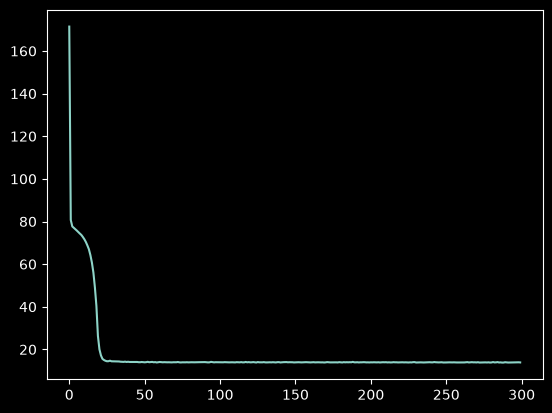

In [54]:
plt.plot(train_history.history["loss"])
plt.show()

In [56]:
model.evaluate(X_test, Y_test)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12.9375 - root_mean_squared_error: 3.5969  


[12.937492370605469, 3.596872568130493]

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


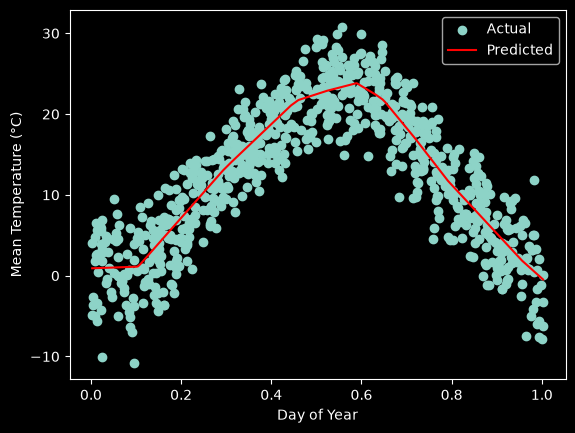

In [58]:
Y_pred = model.predict(X_test)

X_plot = X_test.flatten()
Y_plot = Y_test.flatten()
Y_pred = Y_pred.flatten()

idx = np.argsort(X_plot)

plt.scatter(X_plot, Y_plot, label="Actual")
plt.plot(
    X_plot[idx],
    Y_pred[idx],
    color="red",
    label="Predicted"
)

plt.xlabel("Day of Year")
plt.ylabel("Mean Temperature (°C)")
plt.legend()
plt.show()